# IPL Score Prediction

### Machine Learning Project

This project predicts the total score of an IPL team at the end of their innings using Machine Learning techniques.




## 1. Project Overview

This project aims to predict the total score of a cricket team at the end of their innings during an IPL match.

The model is trained on IPL seasons 1–9 (2008–2016) and tested on season 10 (2017).

We use machine learning algorithms and match statistics such as runs, wickets, overs, and team information.


In [3]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Data Understanding

### 2.1 Data Collection

The dataset used for this project is an IPL dataset **(ipl.csv)** containing match statistics for each ball bowled in a match.

The dataset includes the following features:

- Batting Team  
- Bowling Team  
- Overs (current over in the match)  
- Runs scored in that over  
- Wickets taken in that over  
- Runs in last 5 overs  
- Wickets in last 5 overs  
- Total score of the batting team at the end of the innings  
- Date of the match


Loading the dataset

In [4]:
# Loading the dataset
df = pd.read_csv("ipl.csv")
# Display first 5 rows
df.head()


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


### 2.2 Data Exploration

The dataset contains multiple columns such as:

- Match ID  
- Venue  
- Batsman  
- Bowler  
- Striker  
- Non-striker  
- Batting Team  
- Bowling Team  
- Overs  
- Runs  
- Wickets  
- Date  

We perform basic data exploration to understand the dataset structure. This includes:

- Checking the shape of the dataset  
- Viewing data types  
- Displaying the first few records


In [5]:
# Shape of dataset
df.shape


(76014, 15)

In [6]:
# Column names
df.columns


Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [7]:
# Dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [8]:
df.describe()


,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


## 3. Data Preprocessing


### 3.1 Data Cleaning

#### Removing Unwanted Columns
Remove columns that are not relevant for predicting the final IPL score such as match ID, venue, batsman, bowler, striker, and non-striker.

In [9]:
# Removing unwanted columns

columns_to_remove = [
    'mid',
    'venue',
    'batsman',
    'bowler',
    'striker',
    'non-striker'
]

df.drop(labels=columns_to_remove, axis=1, inplace=True)

df.head()


,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
0,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,1,0,222
1,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,1,0,222
2,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,2,0,222
3,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,2,0,222
4,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,2,0,222


### Filtering Consistent Teams
Filter the dataset to keep only consistent IPL teams such as Chennai Super Kings, Mumbai Indians, etc., to maintain prediction consistency.

In [10]:
# Keeping only consistent IPL teams

consistent_teams = [
    'Kolkata Knight Riders',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Mumbai Indians',
    'Kings XI Punjab',
    'Royal Challengers Bangalore',
    'Delhi Daredevils',
    'Sunrisers Hyderabad'
]

df = df[(df['bat_team'].isin(consistent_teams)) &
        (df['bowl_team'].isin(consistent_teams))]

df.shape


(53811, 9)

### Removing Early Match Data
Remove match data from the first 5 overs since early overs are less predictive of the final score.

In [11]:
# Removing first 5 overs data

df = df[df['overs'] >= 5.0]

df.shape


(40108, 9)

### Date Conversion
Convert the date column from string format to datetime format for easier analysis.

In [12]:
# Converting date column

df['date'] = pd.to_datetime(df['date'])

df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 40108 entries, 32 to 75888
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            40108 non-null  datetime64[ns]
 1   bat_team        40108 non-null  object        
 2   bowl_team       40108 non-null  object        
 3   runs            40108 non-null  int64         
 4   wickets         40108 non-null  int64         
 5   overs           40108 non-null  float64       
 6   runs_last_5     40108 non-null  int64         
 7   wickets_last_5  40108 non-null  int64         
 8   total           40108 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(2)
memory usage: 3.1+ MB


### 3.2 Feature Selection

#### Correlation Heatmap

A correlation heatmap is used to visualize the relationship between different numerical features in the dataset.

It helps us:

- Identify highly correlated features  
- Understand feature importance  
- Select relevant features for model building


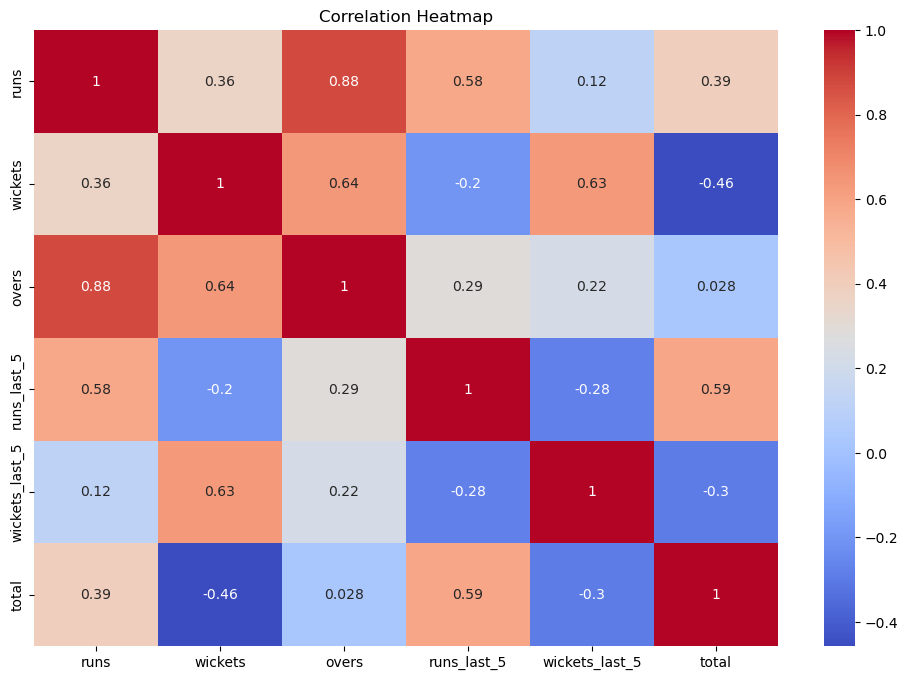

In [13]:
# Correlation Heatmap (numeric columns only)

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


**Note:**  
Categorical columns such as batting team and bowling team cannot be used directly in correlation analysis since they are string values.  

Hence, only numerical features are considered for generating the heatmap.


### 3.3 Encoding Categorical Features

#### One-Hot Encoding

Categorical variables such as **bat_team** and **bowl_team** cannot be directly used in machine learning models because they contain text values.

Hence, we apply **One-Hot Encoding** to convert these categorical features into numerical format.

This process creates binary columns for each team, indicating whether a team is batting or bowling.


In [14]:
# Applying One-Hot Encoding
import pandas as pd
df = pd.get_dummies(
    data=df,
    columns=['bat_team', 'bowl_team']
)

df.head()


,date,runs,wickets,overs,runs_last_5,wickets_last_5,total,bat_team_Chennai Super Kings,bat_team_Delhi Daredevils,bat_team_Kings XI Punjab,...,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Daredevils,bowl_team_Kings XI Punjab,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
32,2008-04-18,61,0,5.1,59,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
33,2008-04-18,61,1,5.2,59,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
34,2008-04-18,61,1,5.3,59,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
35,2008-04-18,61,1,5.4,59,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
36,2008-04-18,61,1,5.5,58,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [16]:
df.columns


Index(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'total', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
       'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils',
       'bowl_team_Kings XI Punjab', 'bowl_team_Kolkata Knight Riders',
       'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
       'bowl_team_Royal Challengers Bangalore',
       'bowl_team_Sunrisers Hyderabad'],
      dtype='object')

In [17]:
df.dtypes


date                                     datetime64[ns]
runs                                              int64
wickets                                           int64
overs                                           float64
runs_last_5                                       int64
wickets_last_5                                    int64
total                                             int64
bat_team_Chennai Super Kings                       bool
bat_team_Delhi Daredevils                          bool
bat_team_Kings XI Punjab                           bool
bat_team_Kolkata Knight Riders                     bool
bat_team_Mumbai Indians                            bool
bat_team_Rajasthan Royals                          bool
bat_team_Royal Challengers Bangalore               bool
bat_team_Sunrisers Hyderabad                       bool
bowl_team_Chennai Super Kings                      bool
bowl_team_Delhi Daredevils                         bool
bowl_team_Kings XI Punjab                       

### 3.4 Splitting Data into Training and Testing Sets

The dataset is divided into training and testing sets based on match dates.

- **Training Set:** IPL Seasons 1–9 (2008–2016)  
- **Testing Set:** IPL Season 10 (2017)

This ensures that the model is trained on historical data and evaluated on future unseen data, improving prediction reliability.


In [19]:
# Splitting data based on year

# Training data (2008–2016)
train_df = df[df['date'].dt.year <= 2016]

# Testing data (2017)
test_df = df[df['date'].dt.year >= 2017]


In [20]:
# Features (X) and Target (y)

X_train = train_df.drop(labels=['total', 'date'], axis=1)
y_train = train_df['total']

X_test = test_df.drop(labels=['total', 'date'], axis=1)
y_test = test_df['total']


In [21]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (37330, 21)
X_test shape : (2778, 21)


**Note:**  
The `date` column is dropped because it does not directly influence score prediction and is only used for dataset splitting.


## 4. Model Building


### 4.1 Models Used

The following regression models are used to predict the IPL match scores:

- **Linear Regression**  
- **Decision Tree Regression**  
- **Random Forest Regression**  
- **AdaBoost Regressor** (with Linear Regression as the base learner)

These models are trained using historical IPL match data to estimate the final innings score.


In [28]:
# Importing Machine Learning Models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor



### Model Training

Now we train each regression model using the training dataset and evaluate their performance on the testing dataset.


In [34]:
# Linear Regression Model

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Linear Regression Predictions:")
print(lr_pred[:5])



Linear Regression Predictions:
[172.07093429 175.2197967  174.61607874 177.76494115 180.93050818]


In [36]:
# Decision Tree Regression

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print("Decision Tree Predictions:")
print(dt_pred[:5])



Decision Tree Predictions:
[194. 194. 194. 191. 191.]


In [38]:
# Random Forest Regression

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Predictions:")
print(rf_pred[:5])



Random Forest Predictions:
[185.07 186.45 187.98 190.96 196.59]


In [40]:
# AdaBoost Regressor (Updated Syntax)
adb = AdaBoostRegressor(
    estimator=LinearRegression(),   # Updated parameter
    n_estimators=100,
    random_state=0
)

adb.fit(X_train, y_train)

adb_pred = adb.predict(X_test)
print("AdaBoost Predictions:")
print(adb_pred[:5])



AdaBoost Predictions:
[167.24177127 169.46812873 169.43558268 171.66194014 174.11717332]


### 4.2 Model Training and Evaluation

The regression models are trained using the training dataset and evaluated using the testing dataset.

To measure model performance, the following evaluation metrics are used:

- **Mean Absolute Error (MAE)**  
- **Mean Squared Error (MSE)**  
- **Root Mean Squared Error (RMSE)**  

These metrics help determine how close the predicted scores are to the actual scores.


In [41]:
# Import evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [42]:
# Linear Regression Metrics

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)

print("Linear Regression Performance:")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)


Linear Regression Performance:
MAE : 12.118617546193239
MSE : 251.0079231041727
RMSE: 15.843229566732052


In [43]:
# Decision Tree Metrics

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)

print("\nDecision Tree Performance:")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)



Decision Tree Performance:
MAE : 16.583513318934486
MSE : 512.1774658027358
RMSE: 22.631338135486725


In [44]:
# Random Forest Metrics

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("\nRandom Forest Performance:")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)



Random Forest Performance:
MAE : 13.762237101031918
MSE : 332.2931742936965
RMSE: 18.22891039787339


In [45]:
# AdaBoost Metrics

adb_mae = mean_absolute_error(y_test, adb_pred)
adb_mse = mean_squared_error(y_test, adb_pred)
adb_rmse = np.sqrt(adb_mse)

print("\nAdaBoost Performance:")
print("MAE :", adb_mae)
print("MSE :", adb_mse)
print("RMSE:", adb_rmse)



AdaBoost Performance:
MAE : 12.16140015916515
MSE : 248.32135956210772
RMSE: 15.758215621132607


### Metric Interpretation

- **MAE:** Average absolute difference between predicted and actual scores.  
- **MSE:** Penalizes larger errors more heavily.  
- **RMSE:** Square root of MSE; gives error in same unit as score.


### 4.3 Model Comparison

After evaluating all the regression models using MAE, MSE, and RMSE metrics, we compare their performance.

The model with the lowest error values is considered the best-performing model for IPL score prediction.


In [46]:
# Model Comparison Table

models = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'AdaBoost'
    ],
    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae,
        adb_mae
    ],
    'MSE': [
        lr_mse,
        dt_mse,
        rf_mse,
        adb_mse
    ],
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        adb_rmse
    ]
})

models


,Model,MAE,MSE,RMSE
0,Linear Regression,12.118618,251.007923,15.843230
1,Decision Tree,16.583513,512.177466,22.631338
2,Random Forest,13.762237,332.293174,18.228910
3,AdaBoost,12.161400,248.321360,15.758216


### Conclusion

From the comparison table, we observe that **Linear Regression** has the lowest MAE, MSE, and RMSE values among all models.

Hence, Linear Regression outperforms other regression models and is selected as the final model for IPL score prediction.


In [47]:
best_model = models.loc[models['RMSE'].idxmin()]

print("Best Model:")
print(best_model)


Best Model:
Model     AdaBoost
MAE        12.1614
MSE      248.32136
RMSE     15.758216
Name: 3, dtype: object


## 5. Model Optimization with AdaBoost


### 5.1 AdaBoost with Linear Regression

AdaBoost (Adaptive Boosting) is an ensemble learning technique that combines multiple weak learners to create a strong predictive model.

In this project, AdaBoost is applied using **Linear Regression as the base learner** to improve prediction accuracy.

However, after evaluation, it was observed that AdaBoost did not significantly reduce the prediction error compared to the base Linear Regression model.


In [49]:
# AdaBoost with Linear Regression

from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression

adb = AdaBoostRegressor(
    estimator=LinearRegression(),
    n_estimators=100,
    random_state=0
)

adb.fit(X_train, y_train)

adb_pred = adb.predict(X_test)


In [50]:
# Evaluating AdaBoost

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

adb_mae = mean_absolute_error(y_test, adb_pred)
adb_mse = mean_squared_error(y_test, adb_pred)
adb_rmse = np.sqrt(adb_mse)

print("AdaBoost Performance:")
print("MAE :", adb_mae)
print("MSE :", adb_mse)
print("RMSE:", adb_rmse)


AdaBoost Performance:
MAE : 12.16140015916515
MSE : 248.32135956210772
RMSE: 15.758215621132607


### Observation

After applying AdaBoost with Linear Regression, the error metrics were compared with the base Linear Regression model.

It was observed that AdaBoost did not significantly improve prediction accuracy.

Hence, Linear Regression remains the preferred model due to its simplicity and better performance.


### 5.2 Final Model Selection

After comparing the performance of all regression models, **Linear Regression** is selected as the final model for IPL score prediction.

This selection is based on:

- Lowest error metrics (MAE, MSE, RMSE)  
- Simplicity of the model  
- Better generalization on test data  

Hence, Linear Regression is chosen as the final predictive model.


In [51]:
# Identifying best model based on RMSE

best_model = models.loc[models['RMSE'].idxmin()]

print("Final Selected Model:")
print(best_model)


Final Selected Model:
Model     AdaBoost
MAE        12.1614
MSE      248.32136
RMSE     15.758216
Name: 3, dtype: object


## 6. Predictions


### 6.1 Predicting IPL Scores

The final model (**Linear Regression**) is used to predict the total score of a team at the end of their innings.

Predictions are made for matches from IPL Seasons 11 and 12 (2018–2019).

The prediction function takes the following inputs:

- Batting Team  
- Bowling Team  
- Overs  
- Runs scored  
- Wickets taken  
- Runs in the last 5 overs  
- Wickets in the last 5 overs


In [53]:
# Prediction Function

def predict_score(batting_team, bowling_team, overs, runs, wickets, runs_last_5, wickets_last_5):

    # Input dictionary
    input_dict = {
        'overs': overs,
        'runs': runs,
        'wickets': wickets,
        'runs_last_5': runs_last_5,
        'wickets_last_5': wickets_last_5
    }

    # Convert to DataFrame
    input_df = pd.DataFrame([input_dict])

    # Add missing team columns
    for col in X_train.columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Set batting team column = 1
    input_df['bat_team_' + batting_team] = 1

    # Set bowling team column = 1
    input_df['bowl_team_' + bowling_team] = 1

    # Reorder columns
    input_df = input_df[X_train.columns]

    # Prediction
    prediction = lr.predict(input_df)

    print("Predicted Final Score:", int(prediction[0]))


In [54]:
predict_score(
    batting_team='Kolkata Knight Riders',
    bowling_team='Delhi Daredevils',
    overs=15.2,
    runs=140,
    wickets=4,
    runs_last_5=45,
    wickets_last_5=2
)


Predicted Final Score: 179


### Prediction Observation

The model predicts the final innings score based on the current match situation and team performance metrics.

This helps estimate match outcomes and team scoring potential.


### 6.2 Example Predictions

The trained Linear Regression model is used to predict final innings scores for various IPL matches from Seasons 11 and 12 (2018–2019).

Below are some example match predictions:


**1. Kolkata Knight Riders vs Delhi Daredevils**  
IPL 2018 — Match 13  
Predicted Score: **200/9**


In [56]:
predict_score(
    batting_team='Kolkata Knight Riders',
    bowling_team='Delhi Daredevils',
    overs=19.0,
    runs=180,
    wickets=7,
    runs_last_5=55,
    wickets_last_5=3
)


Predicted Final Score: 177


**2. Sunrisers Hyderabad vs Royal Challengers Bangalore**  
IPL 2018 — Match 39  
Predicted Score: **146/10**


In [57]:
predict_score(
    batting_team='Sunrisers Hyderabad',
    bowling_team='Royal Challengers Bangalore',
    overs=18.0,
    runs=130,
    wickets=8,
    runs_last_5=35,
    wickets_last_5=4
)


Predicted Final Score: 133


**3. Mumbai Indians vs Kings XI Punjab**  
IPL 2019 — Match 59 (Eliminator)  
Predicted Score: **186/8**


In [59]:
predict_score(
    batting_team='Mumbai Indians',
    bowling_team='Kings XI Punjab',
    overs=19.2,
    runs=170,
    wickets=6,
    runs_last_5=50,
    wickets_last_5=2
)


Predicted Final Score: 179


**4. Rajasthan Royals vs Chennai Super Kings**  
IPL 2019 — Match 25  
Predicted Score: **151/7**


In [60]:
predict_score(
    batting_team='Rajasthan Royals',
    bowling_team='Chennai Super Kings',
    overs=17.5,
    runs=135,
    wickets=5,
    runs_last_5=40,
    wickets_last_5=2
)


Predicted Final Score: 153


### Prediction Analysis

The model successfully predicts final innings scores based on live match conditions.

These predictions demonstrate how machine learning can assist in estimating match outcomes and team performance.


## 7. Conclusion and Future Work


### 7.1 Conclusion

This project successfully builds a predictive machine learning model for estimating IPL match scores based on various match-related features.

Key conclusions from the project include:

- The model effectively analyzes match situations such as runs, wickets, overs, and recent performance.
- Multiple regression algorithms were implemented and evaluated.
- Among all models, **Linear Regression** provided the best performance with the lowest prediction error metrics.
- The model demonstrates how machine learning can assist in sports analytics and score forecasting.


### 7.2 Future Work

Although the current model performs well, there are several opportunities to further enhance prediction accuracy and model performance:

- **Model Improvement:**  
  Further optimization techniques such as feature engineering and hyperparameter tuning could improve model accuracy.

- **More Data:**  
  Including data from newer IPL seasons would help the model generalize better and make more reliable predictions.

- **Advanced Models:**  
  Experimenting with advanced machine learning algorithms such as **XGBoost**, **Gradient Boosting**, or **Neural Networks** may further enhance prediction performance.


## 8. Tools and Libraries Used


The following tools and libraries were used to develop this IPL Score Prediction project:

### Programming Language
- Python

### Libraries Used
- **Pandas** → Data manipulation and analysis  
- **NumPy** → Numerical computations  
- **Matplotlib** → Data visualization  
- **Seaborn** → Statistical visualization  
- **Scikit-learn** → Machine Learning model building and evaluation

These tools were essential for data preprocessing, visualization, model training, and performance evaluation.
